# 🔬 Chip Dataset 

**Dataset:** `chip_dataset.csv` — a collection of CPU and GPU specifications spanning ~25 years of semiconductor history.

**Objectives:**
1. Explore missingness in categorical and numerical features
2. Develop and apply a principled missing-value strategy
3. Drop non-consequential fields
4. Transform temporal data to correct datetime format
5. Full EDA validating 8 key industry assumptions
6. Compute and visualise feature correlations
7. Encode data for modelling

---


## 0. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Global style ────────────────────────────────────────────────────
PALETTE = {
    'CPU': '#4C72B0', 'GPU': '#DD8452',
    'primary': '#2C3E50', 'accent': '#E74C3C',
    'green': '#27AE60', 'purple': '#8E44AD'
}
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'grid.color': '#EEEEEE',
})



---
## 1. Load Data & Initial Inspection




In [2]:
df_raw = pd.read_csv(r'C:\Users\Lenovo\Desktop\Zindua Python\Machine Leaarning Foundations\0105-data-prep-project-ogwaanto\chip_dataset.csv')
print(df_raw.shape)
df_raw.head()


(4945, 13)


,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,AMD Athlon 1000,CPU,6/5/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
1,AMD Athlon 1000,CPU,10/31/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
2,AMD Athlon 1100,CPU,8/14/00,180,60,120,37,1100.0,NaN,AMD,NaN,NaN,NaN
3,AMD Athlon 1133,CPU,10/31/00,180,63,120,37,1133.0,NaN,AMD,NaN,NaN,NaN
4,AMD Athlon 1200,CPU,10/31/00,180,66,120,37,1200.0,NaN,AMD,NaN,NaN,NaN


In [4]:
df_raw.dtypes


Product                      str
Type                         str
Release Date                 str
Process Size (nm)            str
TDP (W)                      str
Die Size (mm^2)              str
Transistors (million)        str
Freq (GHz)               float64
Foundry                      str
Vendor                       str
FP16 GFLOPS              float64
FP32 GFLOPS              float64
FP64 GFLOPS              float64
dtype: object

In [5]:
df_raw.describe(include='all')


,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
count,4945,4945,4746,4945,4508,4593,4390,4508.000000,4330,4945,800.000000,1685.000000,1278.000000
unique,4567,2,1280,29,211,247,248,NaN,10,9,NaN,NaN,NaN
top,AMD Sempron 2800+,GPU,9/1/13,14,unknown,unknown,unknown,NaN,TSMC,AMD,NaN,NaN,NaN
freq,9,2714,58,592,454,228,251,NaN,2202,1689,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1615.430790,NaN,NaN,19033.061063,5403.009359,1096.608263
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1084.641452,NaN,NaN,44865.341218,11492.095538,5232.537404
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,10.020000,12.800000,3.600000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,650.000000,NaN,NaN,1299.500000,384.000000,59.247500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1400.000000,NaN,NaN,6136.500000,1248.000000,136.350000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2500.000000,NaN,NaN,20175.000000,5069.000000,382.450000


---
## 2. Missingness Analysis

Standardise "unknown" strings to `NaN`



In [6]:
df = df_raw.copy()


for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace({'unknown': np.nan, 'Unknown': np.nan})


num_like = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
            'Transistors (million)', 'Freq (GHz)',
            'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']
for col in num_like:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print(df.dtypes)


Product                      str
Type                         str
Release Date                 str
Process Size (nm)        float64
TDP (W)                  float64
Die Size (mm^2)          float64
Transistors (million)    float64
Freq (GHz)               float64
Foundry                      str
Vendor                       str
FP16 GFLOPS              float64
FP32 GFLOPS              float64
FP64 GFLOPS              float64
dtype: object


Missing-Value Summary Table

Quantify missing counts and percentages per column, split by dtype.


In [7]:
miss       = df.isnull().sum()
miss_pct   = (miss / len(df) * 100).round(2)
miss_df    = pd.DataFrame({
    'Missing Count': miss,
    'Missing %':     miss_pct,
    'Dtype':         df.dtypes
}).sort_values('Missing %', ascending=False)

miss_df.style.background_gradient(
    subset=['Missing %'], cmap='YlOrRd'
).format({'Missing %': '{:.2f}%'})


,Missing Count,Missing %,Dtype
FP16 GFLOPS,4145,83.82%,float64
FP64 GFLOPS,3667,74.16%,float64
FP32 GFLOPS,3260,65.93%,float64
TDP (W),891,18.02%,float64
Transistors (million),806,16.30%,float64
Die Size (mm^2),716,14.48%,float64
Foundry,615,12.44%,str
Freq (GHz),437,8.84%,float64
Release Date,199,4.02%,str
Process Size (nm),58,1.17%,float64


### Missingness Visualisations with `missingno`



| Plot | What it shows |
|------|--------------|
| **Matrix** | Row-level pattern  where in the dataset NaN clusters appear |
| **Bar** | Column completeness at a glance |
| **Heatmap** | Pairwise co-occurrence of missingness (nullity correlation) |
| **Dendrogram** | Hierarchical clustering of nullity patterns |


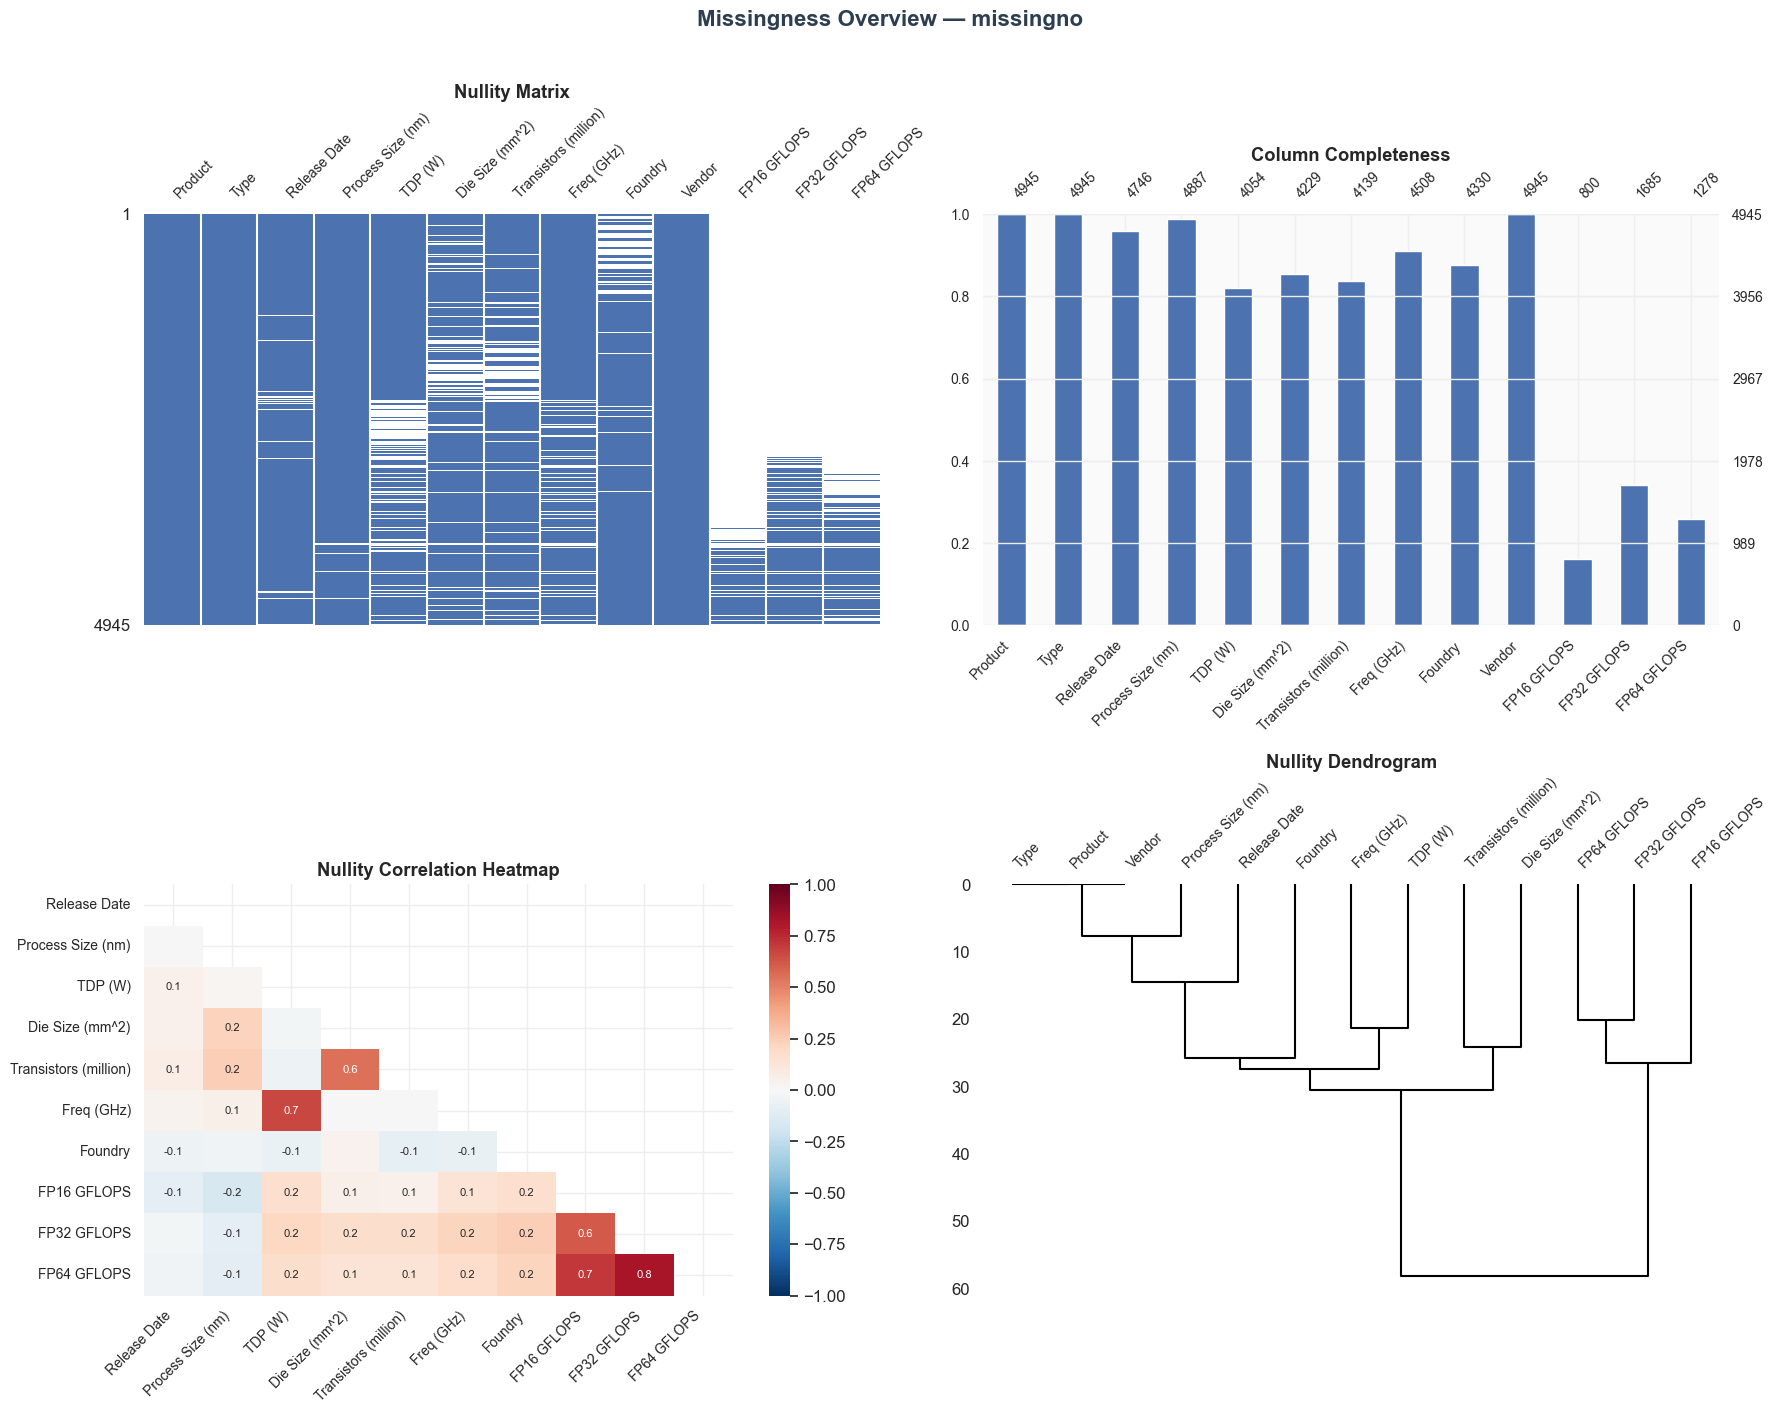

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Missingness Overview — missingno', fontsize=16,
             fontweight='bold', color=PALETTE['primary'], y=1.01)

# 1. Matrix
msno.matrix(df, ax=axes[0, 0], sparkline=False, fontsize=10,
            color=(0.30, 0.45, 0.69))
axes[0, 0].set_title('Nullity Matrix', fontweight='bold')

# 2. Bar
msno.bar(df, ax=axes[0, 1], fontsize=10, color='#4C72B0')
axes[0, 1].set_title('Column Completeness', fontweight='bold')

# 3. Heatmap
msno.heatmap(df, ax=axes[1, 0], fontsize=10, cmap='RdBu_r')
axes[1, 0].set_title('Nullity Correlation Heatmap', fontweight='bold')

# 4. Dendrogram
msno.dendrogram(df, ax=axes[1, 1], fontsize=10)
axes[1, 1].set_title('Nullity Dendrogram', fontweight='bold')

plt.tight_layout()
plt.savefig('missingness_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()


**Key observations:**

- **FP16/FP32/FP64 GFLOPS** are missing in 66–84 % of rows these are GPU-only metrics; most CPU rows will never have them.
- The **nullity heatmap** shows strong co-missingness among the three GFLOPS columns (they all appear or all disappear together), and moderate co-missingness between TDP/Die Size/Transistors.
- The **dendrogram** groups GFLOPS together as one cluster and TDP/Die Size/Transistors/Freq as another, confirming they share the same missingness mechanism.
- **Foundry** and **Release Date** have modest, largely random missingness (< 13 %).


In [9]:
# Separate categorical vs numerical missing summary
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(df[cat_cols].isnull().sum().to_string())
print(df[num_cols].isnull().sum().to_string())


Product           0
Type              0
Release Date    199
Foundry         615
Vendor            0
Process Size (nm)          58
TDP (W)                   891
Die Size (mm^2)           716
Transistors (million)     806
Freq (GHz)                437
FP16 GFLOPS              4145
FP32 GFLOPS              3260
FP64 GFLOPS              3667


---
## 3. Missing Value Strategy

Apply column-specific strategies based on distribution shape, missingness rate, and domain context.




In [10]:
df_clean = df.copy()

# ── Group-median imputation ──────────────────────────────────────
impute_cols = ['TDP (W)', 'Die Size (mm^2)', 'Transistors (million)',
               'Freq (GHz)', 'Process Size (nm)']
for col in impute_cols:
    df_clean[col] = df_clean.groupby('Type')[col].transform(
        lambda x: x.fillna(x.median())
    )

# ── Foundry: fill missing with explicit 'Unknown' category ────────
df_clean['Foundry'] = df_clean['Foundry'].fillna('Unknown')

# GFLOPS columns: intentionally left as NaN


print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Release Date     199
FP16 GFLOPS     4145
FP32 GFLOPS     3260
FP64 GFLOPS     3667
dtype: int64


After imputation the only remaining `NaN` values are the intentionally-retained GFLOPS columns and the small set of `Release Date` / year/month values


---
## 4. Drop Non-Consequential Fields

`Product` is a near-unique free-text identifier (4,567 unique values across 4,945 rows).  
It is essentially a row label.  
Keeping it would bloat encoding 


In [11]:
print(f"Unique products: {df_clean['Product'].nunique()} / {len(df_clean)} rows")
df_clean.drop(columns=['Product'], inplace=True)
print("'Product' dropped. Remaining columns:", df_clean.columns.tolist())


Unique products: 4567 / 4945 rows
'Product' dropped. Remaining columns: ['Type', 'Release Date', 'Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (GHz)', 'Foundry', 'Vendor', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']


---
## 5. Temporal Data Transformation
 
We parse with `format='%m/%d/%y'` and then correct any future dates (> 2026) by subtracting 100 years.

We also extract `Release Year` and `Release Month` as standalone integer features.


In [12]:
df_clean['Release Date'] = pd.to_datetime(
    df_clean['Release Date'], format='%m/%d/%y', errors='coerce'
)

# Correct two-digit-year misinterpretation (e.g. 2099 → 1999)
future_mask = df_clean['Release Date'].dt.year > 2026
df_clean.loc[future_mask, 'Release Date'] = (
    df_clean.loc[future_mask, 'Release Date']
    .apply(lambda d: d.replace(year=d.year - 100) if pd.notna(d) else d)
)

df_clean['Release Year']  = df_clean['Release Date'].dt.year
df_clean['Release Month'] = df_clean['Release Date'].dt.month

print(df_clean[['Release Date', 'Release Year', 'Release Month']].head(8))
print(f"\nRelease Year range: {df_clean['Release Year'].min():.0f} – {df_clean['Release Year'].max():.0f}")


  Release Date  Release Year  Release Month
0   2000-06-05        2000.0            6.0
1   2000-10-31        2000.0           10.0
2   2000-08-14        2000.0            8.0
3   2000-10-31        2000.0           10.0
4   2000-10-31        2000.0           10.0
5   2000-10-17        2000.0           10.0
6   2000-06-05        2000.0            6.0
7   2000-06-05        2000.0            6.0

Release Year range: 1999 – 2024


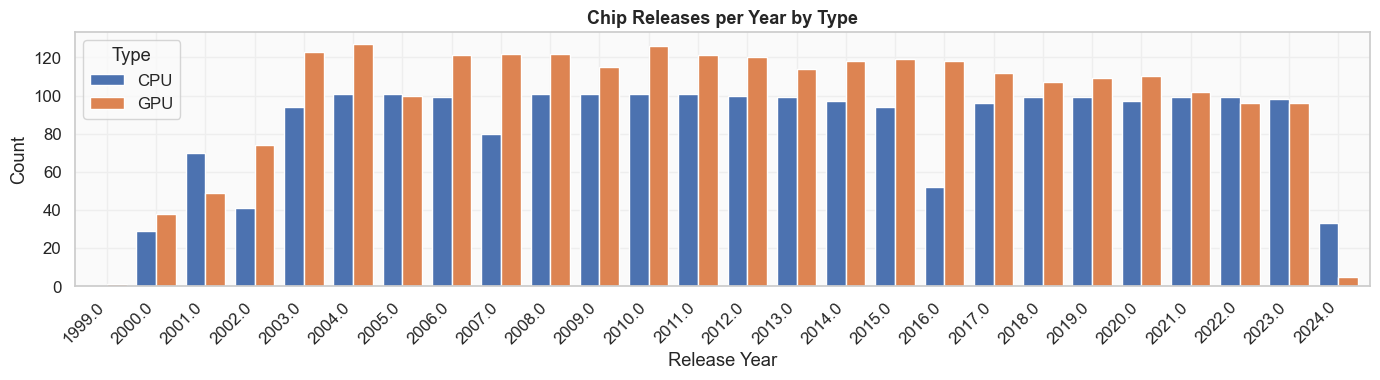

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
df_clean.dropna(subset=['Release Year']).groupby(
    ['Release Year', 'Type']
).size().unstack().plot(
    kind='bar', ax=ax, color=[PALETTE['CPU'], PALETTE['GPU']],
    edgecolor='white', width=0.8
)
ax.set_title('Chip Releases per Year by Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Release Year')
ax.set_ylabel('Count')
ax.legend(title='Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('releases_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Full EDA & Assumption Validation

We test eight well-known semiconductor industry assumptions against the data.


In [14]:
gpu = df_clean[df_clean['Type'] == 'GPU'].copy()
cpu = df_clean[df_clean['Type'] == 'CPU'].copy()
print(f"GPU rows: {len(gpu):,}   CPU rows: {len(cpu):,}")


GPU rows: 2,714   CPU rows: 2,231


### Assumption 1 Moore's Law Still Holds, Especially in GPUs

**Moore's Law** predicts transistor count doubles roughly every **2 years**.  
We fit a log-linear trend to median transistors per year for CPUs and GPUs and extract the doubling period.


CPU: doubles every 4.0 yrs | R² = 0.723
GPU: doubles every 2.4 yrs | R² = 0.984


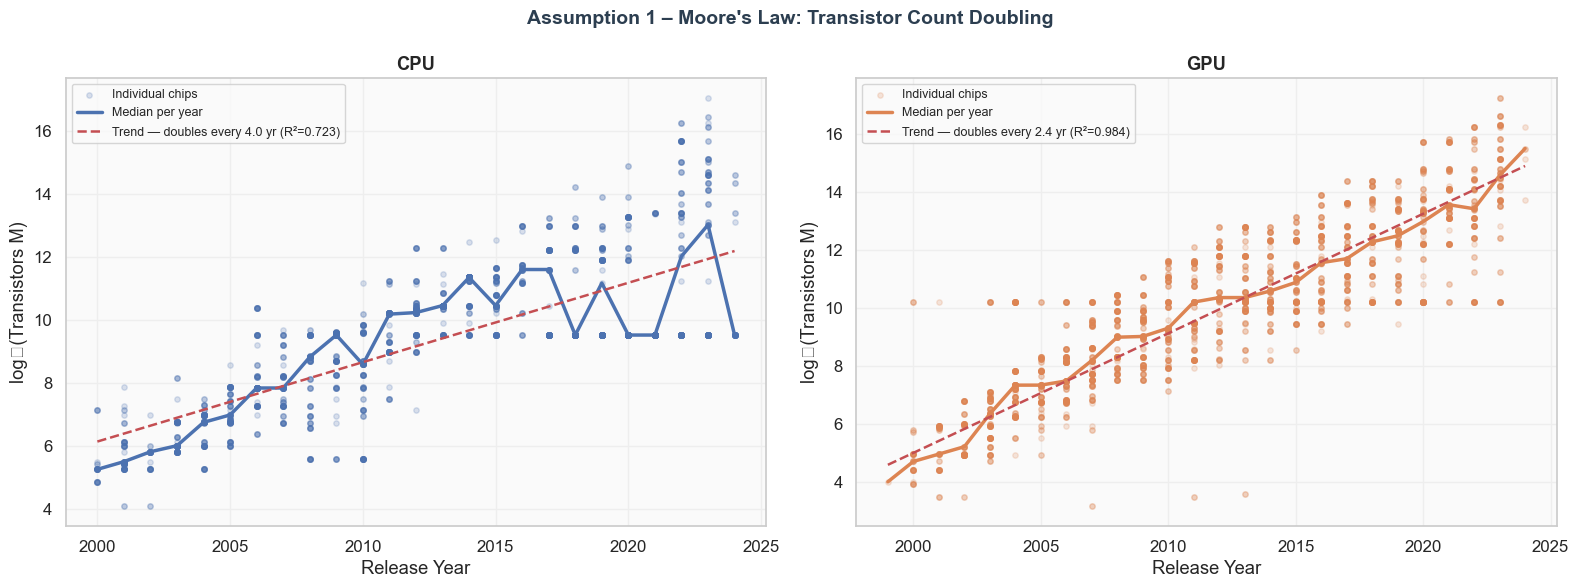

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 1 – Moore's Law: Transistor Count Doubling",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, data, label, color in [
    (axes[0], cpu, 'CPU', PALETTE['CPU']),
    (axes[1], gpu, 'GPU', PALETTE['GPU']),
]:
    d = data.dropna(subset=['Release Year', 'Transistors (million)'])
    yr = d.groupby('Release Year')['Transistors (million)'].median().reset_index()

    ax.scatter(d['Release Year'], np.log2(d['Transistors (million)'] + 1),
               alpha=0.2, color=color, s=15, label='Individual chips')
    ax.plot(yr['Release Year'], np.log2(yr['Transistors (million)'] + 1),
            color=color, linewidth=2.5, label='Median per year')

    m, b, r, p, _ = stats.linregress(
        yr['Release Year'], np.log2(yr['Transistors (million)'] + 1)
    )
    doubling = round(1 / m, 2)
    x = np.linspace(yr['Release Year'].min(), yr['Release Year'].max(), 100)
    ax.plot(x, m * x + b, 'r--', linewidth=1.8,
            label=f'Trend — doubles every {doubling:.1f} yr (R²={r**2:.3f})')

    ax.set_xlabel('Release Year'); ax.set_ylabel('log₂(Transistors M)')
    ax.set_title(f'{label}', fontweight='bold')
    ax.legend(fontsize=9)
    print(f"{label}: doubles every {doubling:.1f} yrs | R² = {r**2:.3f}")

plt.tight_layout()
plt.savefig('moores_law.png', dpi=150, bbox_inches='tight')
plt.show()


Moore's Law holds strongly in GPUs (doubling every ~2.4 yr, R²≈0.98) and more loosely in CPUs (~4 yr, R²≈0.72), consistent with CPUs hitting physical frequency limits earlier.


### Assumption 2  Dennard Scaling Is Still Valid in General

**Dennard Scaling** predicts that as transistors shrink, power density stays roughly constant — achievable only by reducing process node size.  
A continuous decline in `Process Size (nm)` over time is evidence the industry has pursued this path.


CPU: 180 nm → 10 nm  (5.6%)
GPU: 250 nm → 5 nm  (2.0%)


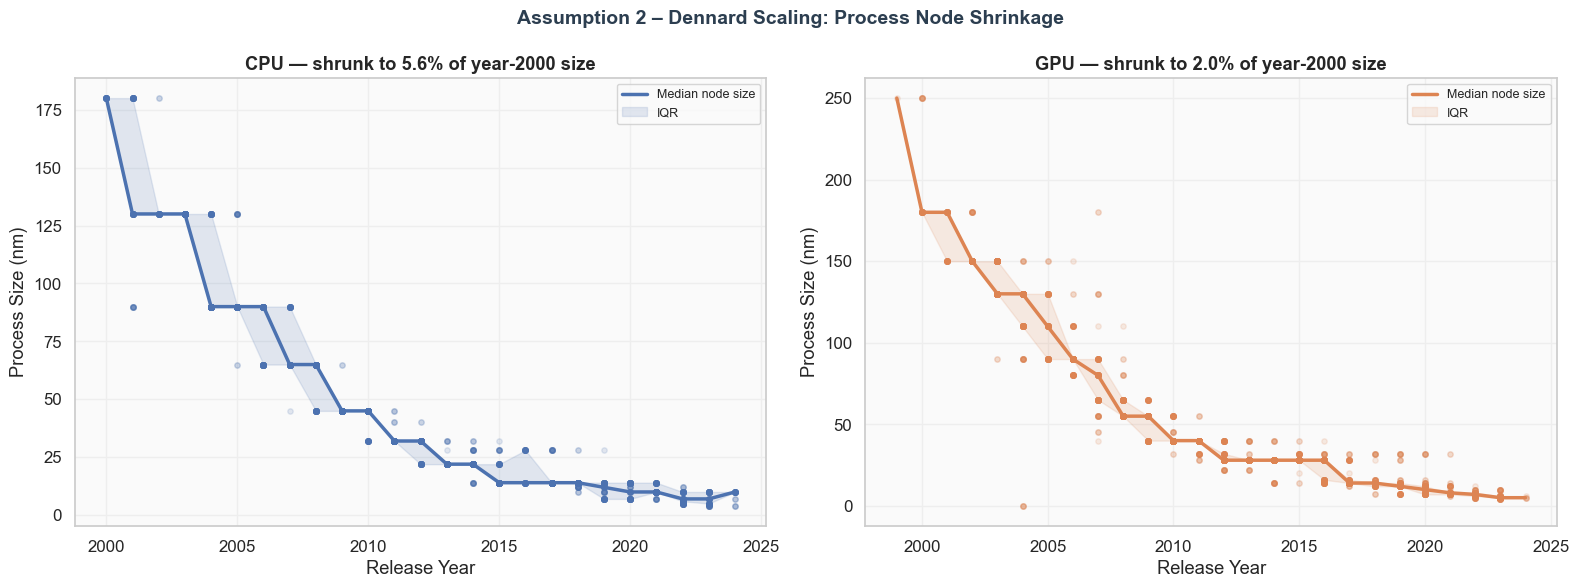

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 2 – Dennard Scaling: Process Node Shrinkage",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, data, label, color in [
    (axes[0], cpu, 'CPU', PALETTE['CPU']),
    (axes[1], gpu, 'GPU', PALETTE['GPU']),
]:
    d = data.dropna(subset=['Release Year', 'Process Size (nm)'])
    yr = d.groupby('Release Year')['Process Size (nm)'].median().reset_index()

    ax.scatter(d['Release Year'], d['Process Size (nm)'],
               alpha=0.15, color=color, s=15)
    ax.plot(yr['Release Year'], yr['Process Size (nm)'],
            color=color, linewidth=2.5, label='Median node size')
    ax.fill_between(yr['Release Year'],
                    d.groupby('Release Year')['Process Size (nm)'].quantile(0.25).values,
                    d.groupby('Release Year')['Process Size (nm)'].quantile(0.75).values,
                    alpha=0.15, color=color, label='IQR')

    shrink = yr.iloc[-1]['Process Size (nm)'] / yr.iloc[0]['Process Size (nm)']
    ax.set_xlabel('Release Year'); ax.set_ylabel('Process Size (nm)')
    ax.set_title(f'{label} — shrunk to {shrink:.1%} of year-2000 size', fontweight='bold')
    ax.legend(fontsize=9)
    print(f"{label}: {yr.iloc[0]['Process Size (nm)']:.0f} nm → {yr.iloc[-1]['Process Size (nm)']:.0f} nm  ({shrink:.1%})")

plt.tight_layout()
plt.savefig('dennard.png', dpi=150, bbox_inches='tight')
plt.show()


Process node has shrunk dramatically — GPU median dropped from ~180 nm to ~5 nm over 25 years (to just 2 % of the original), and CPU from ~180 nm to ~10 nm (5.6 %). The continuous downward trend confirms the industry has relentlessly pursued Dennard-compatible node scaling.


### Assumption 3 CPUs Have Higher Clock Frequencies, But GPUs Are Catching Up

CPUs are designed for **single-thread latency** — high frequency is critical.  
GPUs optimise for **throughput via massive parallelism**, historically at lower clocks.  
We expect CPU median frequency to exceed GPU, but the gap to narrow over time.


CPU median frequency: 2,500 MHz
GPU median frequency: 650 MHz


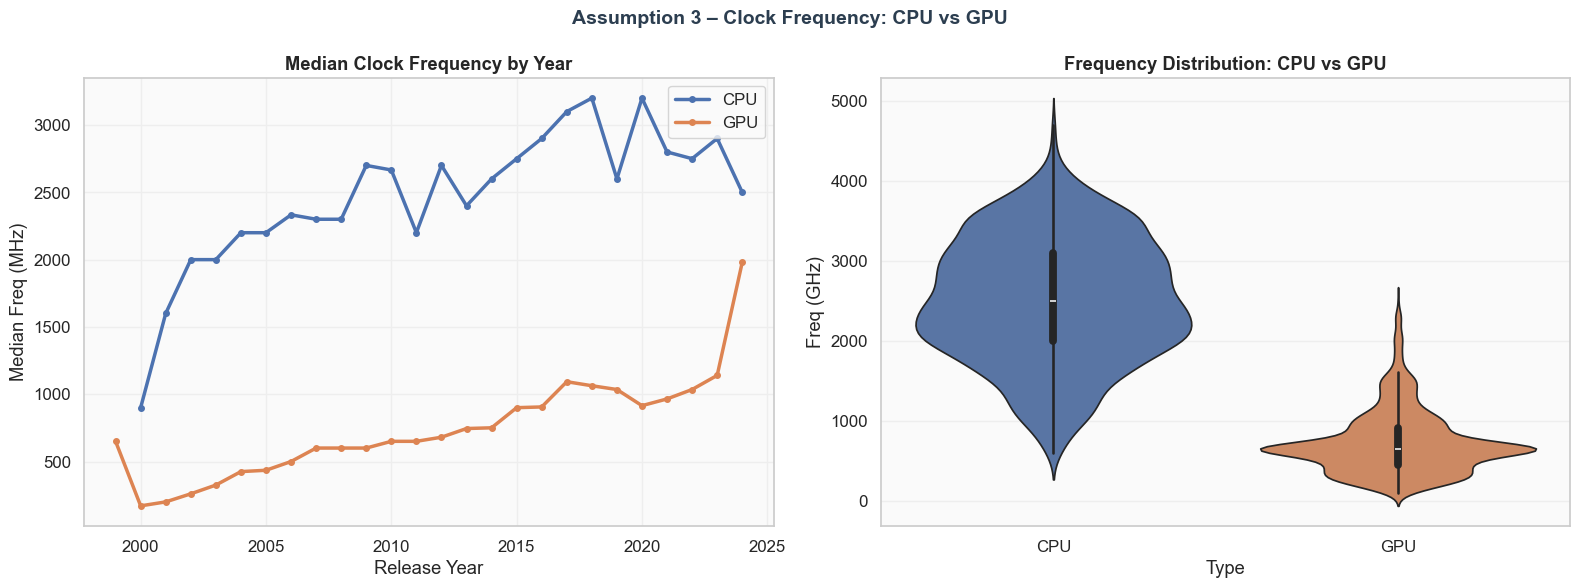

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 3 – Clock Frequency: CPU vs GPU",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

d_freq = df_clean.dropna(subset=['Release Year', 'Freq (GHz)'])
yr_freq = (d_freq.groupby(['Release Year', 'Type'])['Freq (GHz)']
           .median().reset_index())

# Line plot
for t, color in [('CPU', PALETTE['CPU']), ('GPU', PALETTE['GPU'])]:
    sub = yr_freq[yr_freq['Type'] == t]
    axes[0].plot(sub['Release Year'], sub['Freq (GHz)'],
                 color=color, linewidth=2.5, marker='o', markersize=4, label=t)
axes[0].set_xlabel('Release Year'); axes[0].set_ylabel('Median Freq (MHz)')
axes[0].set_title('Median Clock Frequency by Year', fontweight='bold')
axes[0].legend()

# KDE / box
sns.violinplot(data=df_clean.dropna(subset=['Freq (GHz)']),
               x='Type', y='Freq (GHz)', palette=PALETTE,
               inner='box', ax=axes[1])
axes[1].set_title('Frequency Distribution: CPU vs GPU', fontweight='bold')

for t in ['CPU', 'GPU']:
    m = df_clean[df_clean['Type'] == t]['Freq (GHz)'].median()
    print(f"{t} median frequency: {m:,.0f} MHz")

plt.tight_layout()
plt.savefig('frequency.png', dpi=150, bbox_inches='tight')
plt.show()


CPU median clock (~2,500 MHz) is nearly 4× higher than GPU median (~650 MHz). The line chart shows GPU frequencies trending upward over time, gradually closing the gap — consistent with the assumption.


### Assumption 4 GPU Performance Doubles Every 1.5 Years

We measure GPU performance as **FP32 GFLOPS** (32-bit floating-point throughput)  the standard benchmark for general GPU compute.  
A log₂ trend fit gives us the empirical doubling period.


GPU FP32 performance doubles every ~2.5 years  (R²=0.926)


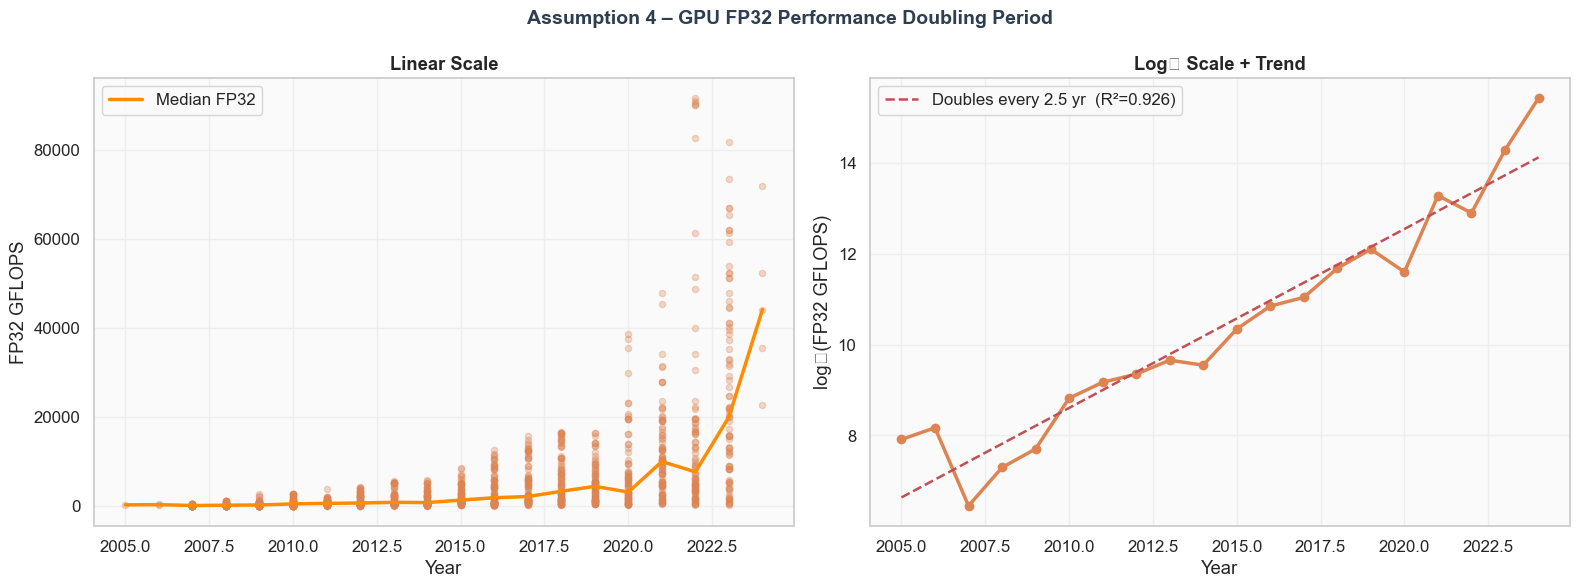

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 4 – GPU FP32 Performance Doubling Period",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

gfp = gpu.dropna(subset=['FP32 GFLOPS', 'Release Year'])
yr_fp = gfp.groupby('Release Year')['FP32 GFLOPS'].median().reset_index()

# Linear scale
axes[0].scatter(gfp['Release Year'], gfp['FP32 GFLOPS'],
                alpha=0.3, color=PALETTE['GPU'], s=20)
axes[0].plot(yr_fp['Release Year'], yr_fp['FP32 GFLOPS'],
             color='darkorange', linewidth=2.5, label='Median FP32')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('FP32 GFLOPS')
axes[0].set_title('Linear Scale', fontweight='bold'); axes[0].legend()

# Log₂ scale + trend
m, b, r, p, _ = stats.linregress(
    yr_fp['Release Year'], np.log2(yr_fp['FP32 GFLOPS'] + 1)
)
doubling = round(1 / m, 2)
x = np.linspace(yr_fp['Release Year'].min(), yr_fp['Release Year'].max(), 100)
axes[1].plot(yr_fp['Release Year'], np.log2(yr_fp['FP32 GFLOPS'] + 1),
             'o-', color=PALETTE['GPU'], linewidth=2.5)
axes[1].plot(x, m * x + b, 'r--', linewidth=1.8,
             label=f'Doubles every {doubling:.1f} yr  (R²={r**2:.3f})')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log₂(FP32 GFLOPS)')
axes[1].set_title('Log₂ Scale + Trend', fontweight='bold'); axes[1].legend()

print(f"GPU FP32 performance doubles every ~{doubling:.1f} years  (R²={r**2:.3f})")

plt.tight_layout()
plt.savefig('gpu_performance.png', dpi=150, bbox_inches='tight')
plt.show()


**Partial** The data shows doubling every **~2.5 years** rather than the claimed 1.5. This is still remarkable growth but just slightly slower than the most optimistic projection. The R²≈0.93 confirms a very consistent exponential trend.


### Assumption 5 GPU Performance Improvement Is a Joint Effect of Smaller Transistors, Larger Die Size, and Higher Frequency

We examine the Pearson correlation (on log-scale FP32) between performance and each of the three drivers.


  FP32 GFLOPS vs Transistors (million)    : r = 0.646
  FP32 GFLOPS vs Die Size (mm^2)          : r = 0.641
  FP32 GFLOPS vs Freq (GHz)               : r = 0.689


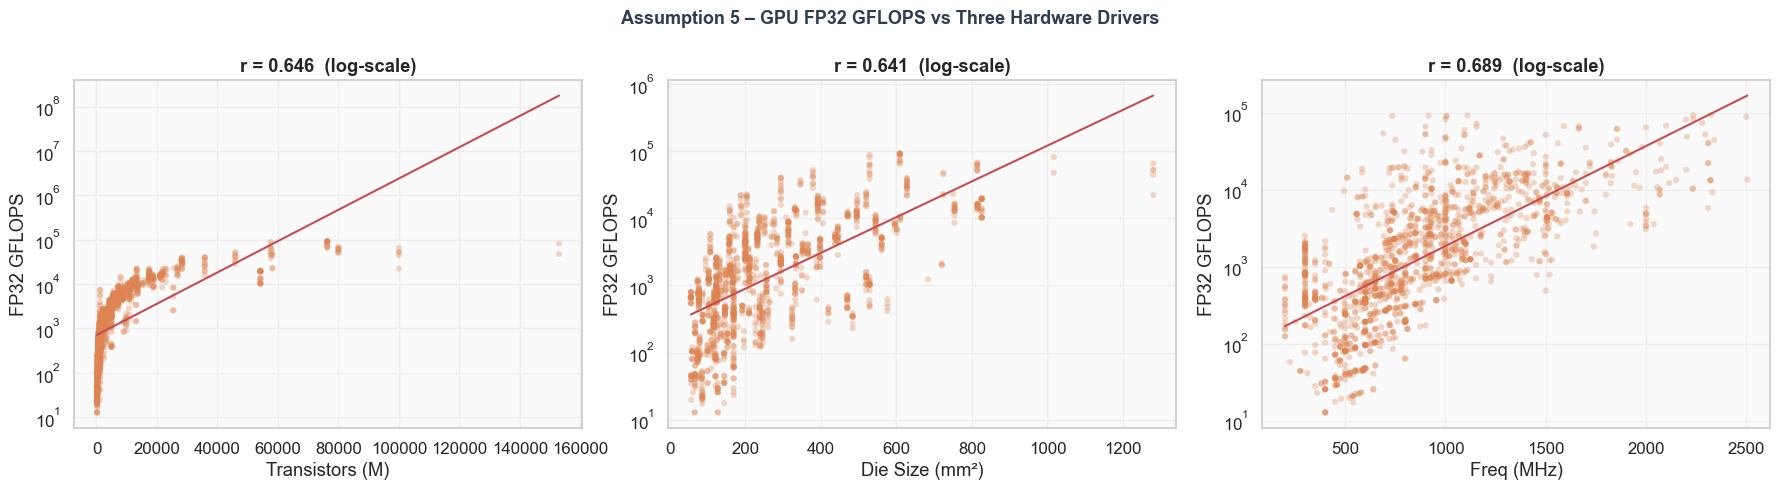

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Assumption 5 – GPU FP32 GFLOPS vs Three Hardware Drivers",
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

gfull = gpu.dropna(subset=['FP32 GFLOPS', 'Transistors (million)',
                            'Die Size (mm^2)', 'Freq (GHz)'])

pairs = [
    ('Transistors (million)', 'Transistors (M)',   axes[0]),
    ('Die Size (mm^2)',        'Die Size (mm²)',    axes[1]),
    ('Freq (GHz)',             'Freq (MHz)',        axes[2]),
]

for feat, lab, ax in pairs:
    ax.scatter(gfull[feat], gfull['FP32 GFLOPS'],
               alpha=0.3, color=PALETTE['GPU'], s=20, edgecolors='none')
    r, p = stats.pearsonr(gfull[feat], np.log1p(gfull['FP32 GFLOPS']))
    # Trend line
    m_, b_ = np.polyfit(gfull[feat], np.log1p(gfull['FP32 GFLOPS']), 1)
    xs = np.linspace(gfull[feat].min(), gfull[feat].max(), 200)
    ax.plot(xs, np.expm1(m_ * xs + b_), 'r-', linewidth=1.5)
    ax.set_xlabel(lab); ax.set_ylabel('FP32 GFLOPS'); ax.set_yscale('log')
    ax.set_title(f'r = {r:.3f}  (log-scale)', fontweight='bold')
    print(f"  FP32 GFLOPS vs {feat:25s}: r = {r:.3f}")

plt.tight_layout()
plt.savefig('joint_effect.png', dpi=150, bbox_inches='tight')
plt.show()


All three drivers show moderate-to-strong positive correlation with FP32 performance (r ≈ 0.64–0.68). No single factor dominates, the improvement is genuinely **multi-factorial**, supporting the joint-effect hypothesis.


### Assumption 6  High-End GPUs Tend to First Use New Semiconductor Technologies

We split GPUs into **high-end** (top quartile FP32 per year) and **low-end** (bottom quartile) and compare their median process node over time.


  High-end GPU median process size: 28 nm
  Low-end GPU median process size: 28 nm


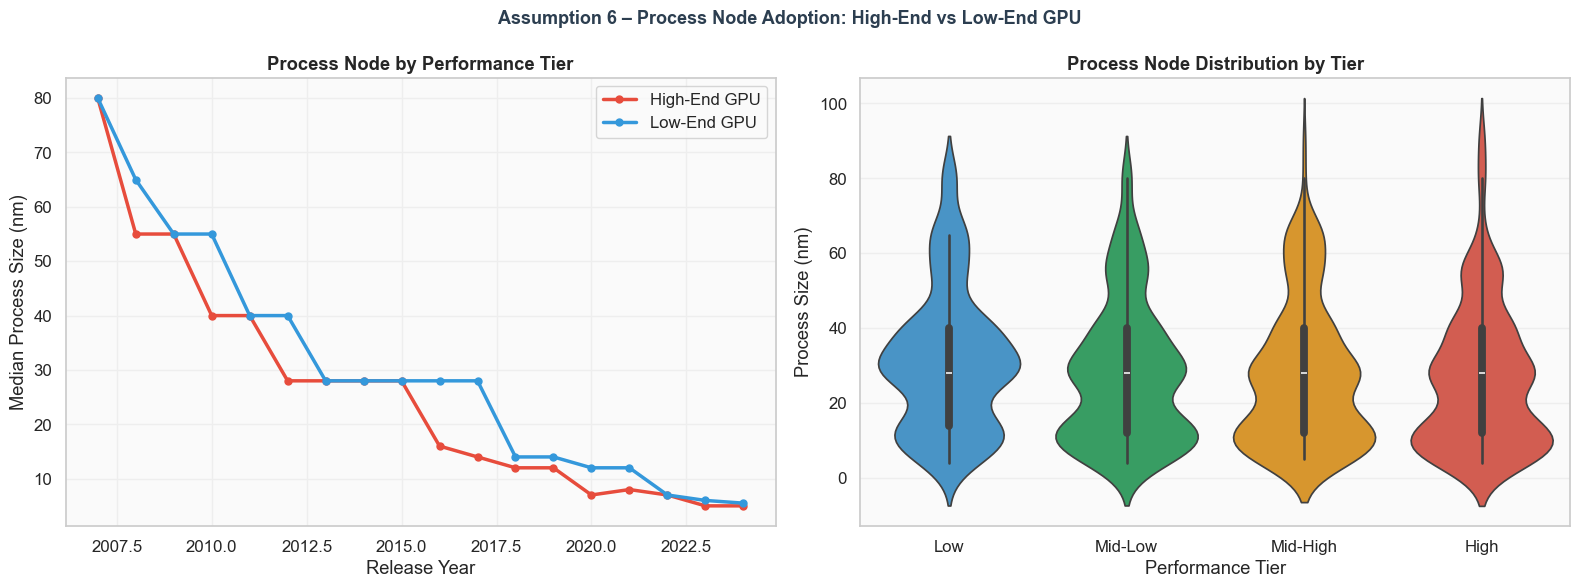

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 6 – Process Node Adoption: High-End vs Low-End GPU",
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

gpu_t = gpu.dropna(subset=['Process Size (nm)', 'Release Year', 'FP32 GFLOPS']).copy()
gpu_t['tier'] = gpu_t.groupby('Release Year')['FP32 GFLOPS'].transform(
    lambda x: pd.qcut(x, q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'],
                      duplicates='drop') if len(x) >= 4 else np.nan
)
tier_sub = gpu_t[gpu_t['tier'].isin(['Low', 'High'])]
yr_tier  = tier_sub.groupby(['Release Year', 'tier'])['Process Size (nm)'].median().reset_index()

for tier, color in [('High', '#E74C3C'), ('Low', '#3498DB')]:
    sub = yr_tier[yr_tier['tier'] == tier]
    axes[0].plot(sub['Release Year'], sub['Process Size (nm)'],
                 color=color, linewidth=2.5, marker='o', markersize=5,
                 label=f'{tier}-End GPU')

axes[0].set_xlabel('Release Year'); axes[0].set_ylabel('Median Process Size (nm)')
axes[0].set_title('Process Node by Performance Tier', fontweight='bold')
axes[0].legend()

# Violin: process size distribution by tier
palette_tier = {'High': '#E74C3C', 'Low': '#3498DB',
                'Mid-High': '#F39C12', 'Mid-Low': '#27AE60'}
gpu_t2 = gpu_t.dropna(subset=['tier'])
sns.violinplot(data=gpu_t2, x='tier',
               y='Process Size (nm)',
               order=['Low', 'Mid-Low', 'Mid-High', 'High'],
               palette=palette_tier, inner='box', ax=axes[1])
axes[1].set_title('Process Node Distribution by Tier', fontweight='bold')
axes[1].set_xlabel('Performance Tier')

for tier in ['High', 'Low']:
    med = tier_sub[tier_sub['tier'] == tier]['Process Size (nm)'].median()
    print(f"  {tier}-end GPU median process size: {med:.0f} nm")

plt.tight_layout()
plt.savefig('highend_process.png', dpi=150, bbox_inches='tight')
plt.show()


The line chart shows high-end GPUs consistently sitting **below** low-end GPUs on the process node axis (smaller = newer technology) throughout the timeline. Low-end GPUs continue using older, larger nodes for several years after high-end cards have moved on exactly as the assumption predicts.


### Assumption 7 — Intel, AMD & NVIDIA Use Comparatively Smaller Process Nodes Than ATI and Other Vendors


  AMD       : median process size = 28 nm
  Intel     : median process size = 22 nm
  VIA       : median process size = 65 nm
  3dfx      : median process size = 215 nm
  ATI       : median process size = 90 nm
  Matrox    : median process size = 150 nm
  NVIDIA    : median process size = 40 nm
  Sony      : median process size = 90 nm
  XGI       : median process size = 130 nm


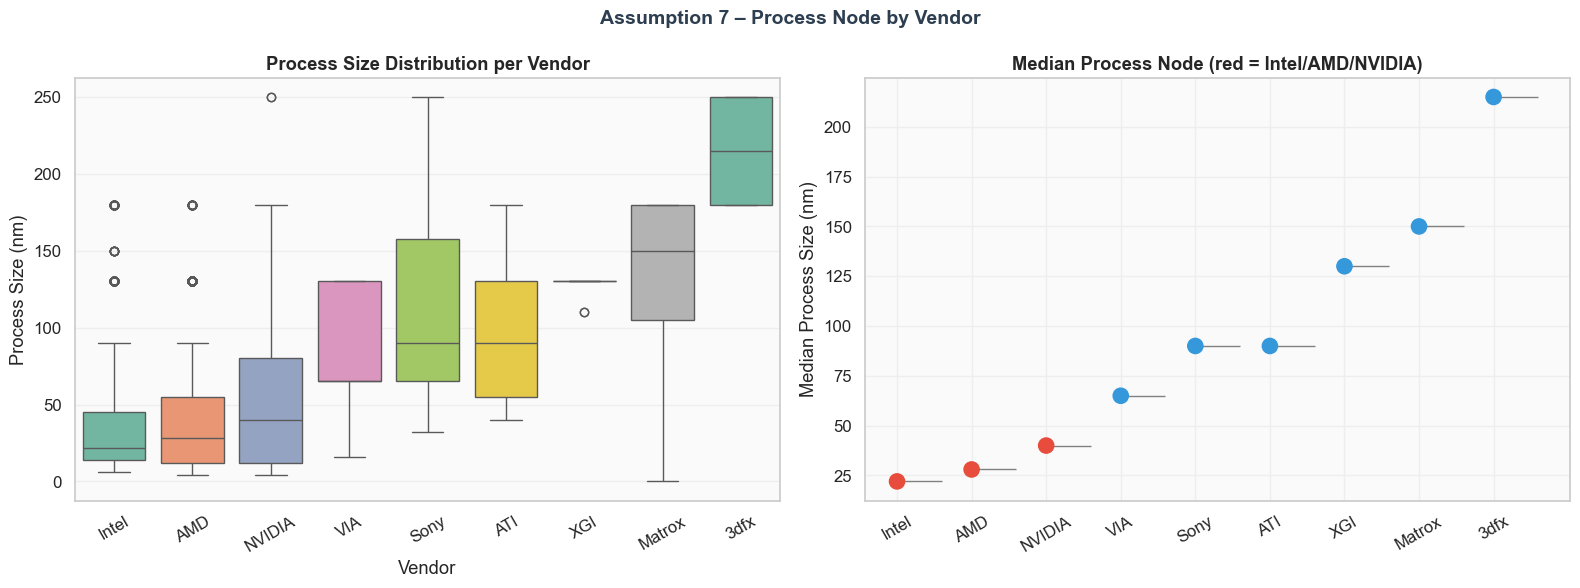

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 7 – Process Node by Vendor",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

vps = df_clean.dropna(subset=['Process Size (nm)']).copy()
vorder = (vps.groupby('Vendor')['Process Size (nm)']
          .median().sort_values().index.tolist())

sns.boxplot(data=vps, x='Vendor', y='Process Size (nm)',
            order=vorder, palette='Set2', ax=axes[0])
axes[0].set_title('Process Size Distribution per Vendor', fontweight='bold')
axes[0].set_xlabel('Vendor'); axes[0].tick_params(axis='x', rotation=30)

# Strip + median dot
medians = vps.groupby('Vendor')['Process Size (nm)'].median().reindex(vorder)
axes[1].hlines(medians.values, xmin=range(len(vorder)),
               xmax=[x+0.6 for x in range(len(vorder))],
               color='grey', linewidth=1)
axes[1].scatter(range(len(medians)), medians.values,
                s=120, zorder=5,
                color=[('#E74C3C' if v in ['Intel','AMD','NVIDIA'] else '#3498DB')
                       for v in medians.index])
axes[1].set_xticks(range(len(vorder))); axes[1].set_xticklabels(vorder, rotation=30)
axes[1].set_ylabel('Median Process Size (nm)')
axes[1].set_title('Median Process Node (red = Intel/AMD/NVIDIA)', fontweight='bold')

for v in vps['Vendor'].unique():
    m = vps[vps['Vendor'] == v]['Process Size (nm)'].median()
    print(f"  {v:10s}: median process size = {m:.0f} nm")

plt.tight_layout()
plt.savefig('vendor_process.png', dpi=150, bbox_inches='tight')
plt.show()


Intel and AMD sit at the lowest median process nodes, followed by NVIDIA. ATI (acquired by AMD in 2006 but historically separate) and niche vendors like Matrox, XGI, and VIA show notably larger median nodes — consistent with the assumption.


### Assumption 8 — TSMC Makes the Highest Number of Chips in the World


TSMC chip count: 2,202  (50.9% of known-foundry chips)


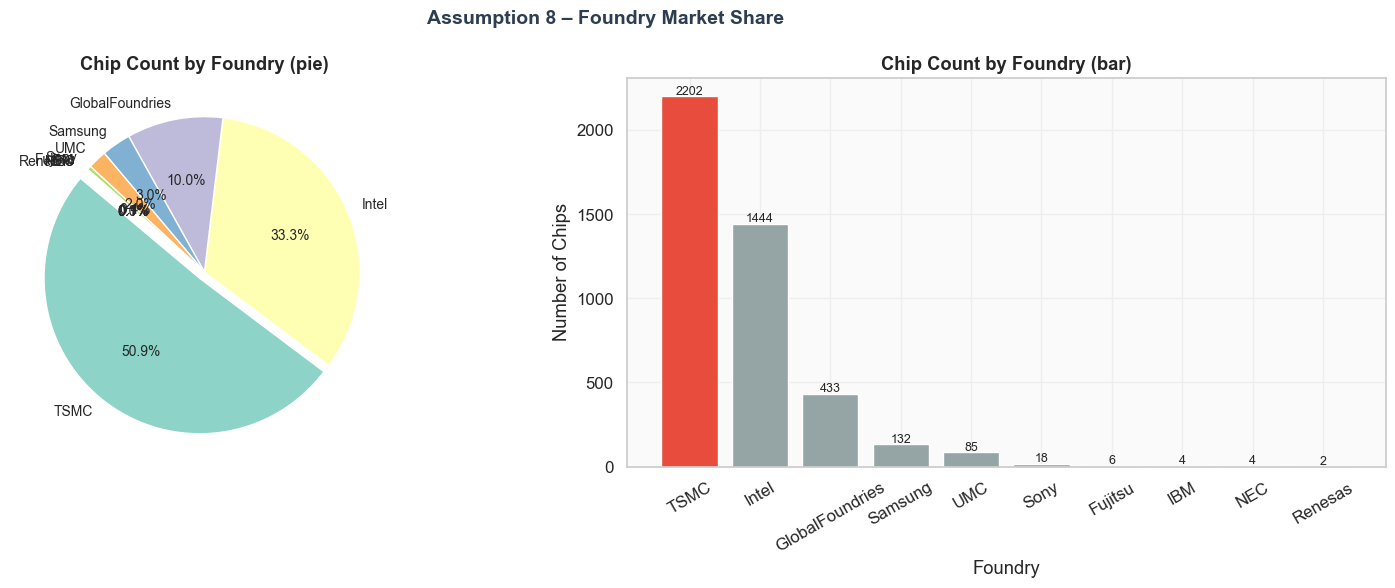

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Assumption 8 – Foundry Market Share",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

foundry_counts = (df_clean[df_clean['Foundry'] != 'Unknown']['Foundry']
                  .value_counts())
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(foundry_counts)))

# Pie
explode = [0.05 if f == 'TSMC' else 0 for f in foundry_counts.index]
axes[0].pie(foundry_counts.values,
            labels=foundry_counts.index,
            autopct='%1.1f%%',
            colors=colors_pie,
            explode=explode,
            startangle=140,
            textprops={'fontsize': 10})
axes[0].set_title('Chip Count by Foundry (pie)', fontweight='bold')

# Bar
bar_colors = ['#E74C3C' if f == 'TSMC' else '#95A5A6' for f in foundry_counts.index]
bars = axes[1].bar(foundry_counts.index, foundry_counts.values,
                   color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Foundry'); axes[1].set_ylabel('Number of Chips')
axes[1].set_title('Chip Count by Foundry (bar)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(bar.get_height()), ha='center', fontsize=9)

tsmc_share = foundry_counts['TSMC'] / foundry_counts.sum() * 100
print(f"TSMC chip count: {foundry_counts['TSMC']:,}  ({tsmc_share:.1f}% of known-foundry chips)")

plt.tight_layout()
plt.savefig('foundry_share.png', dpi=150, bbox_inches='tight')
plt.show()


TSMC accounts for **~51 %** of all chips with a known foundry, more than Intel (#2 at ~31 %) and GlobalFoundries (#3 at ~9 %) combined. This confirms TSMC's dominant position in the dataset.


###  General Feature Distributions


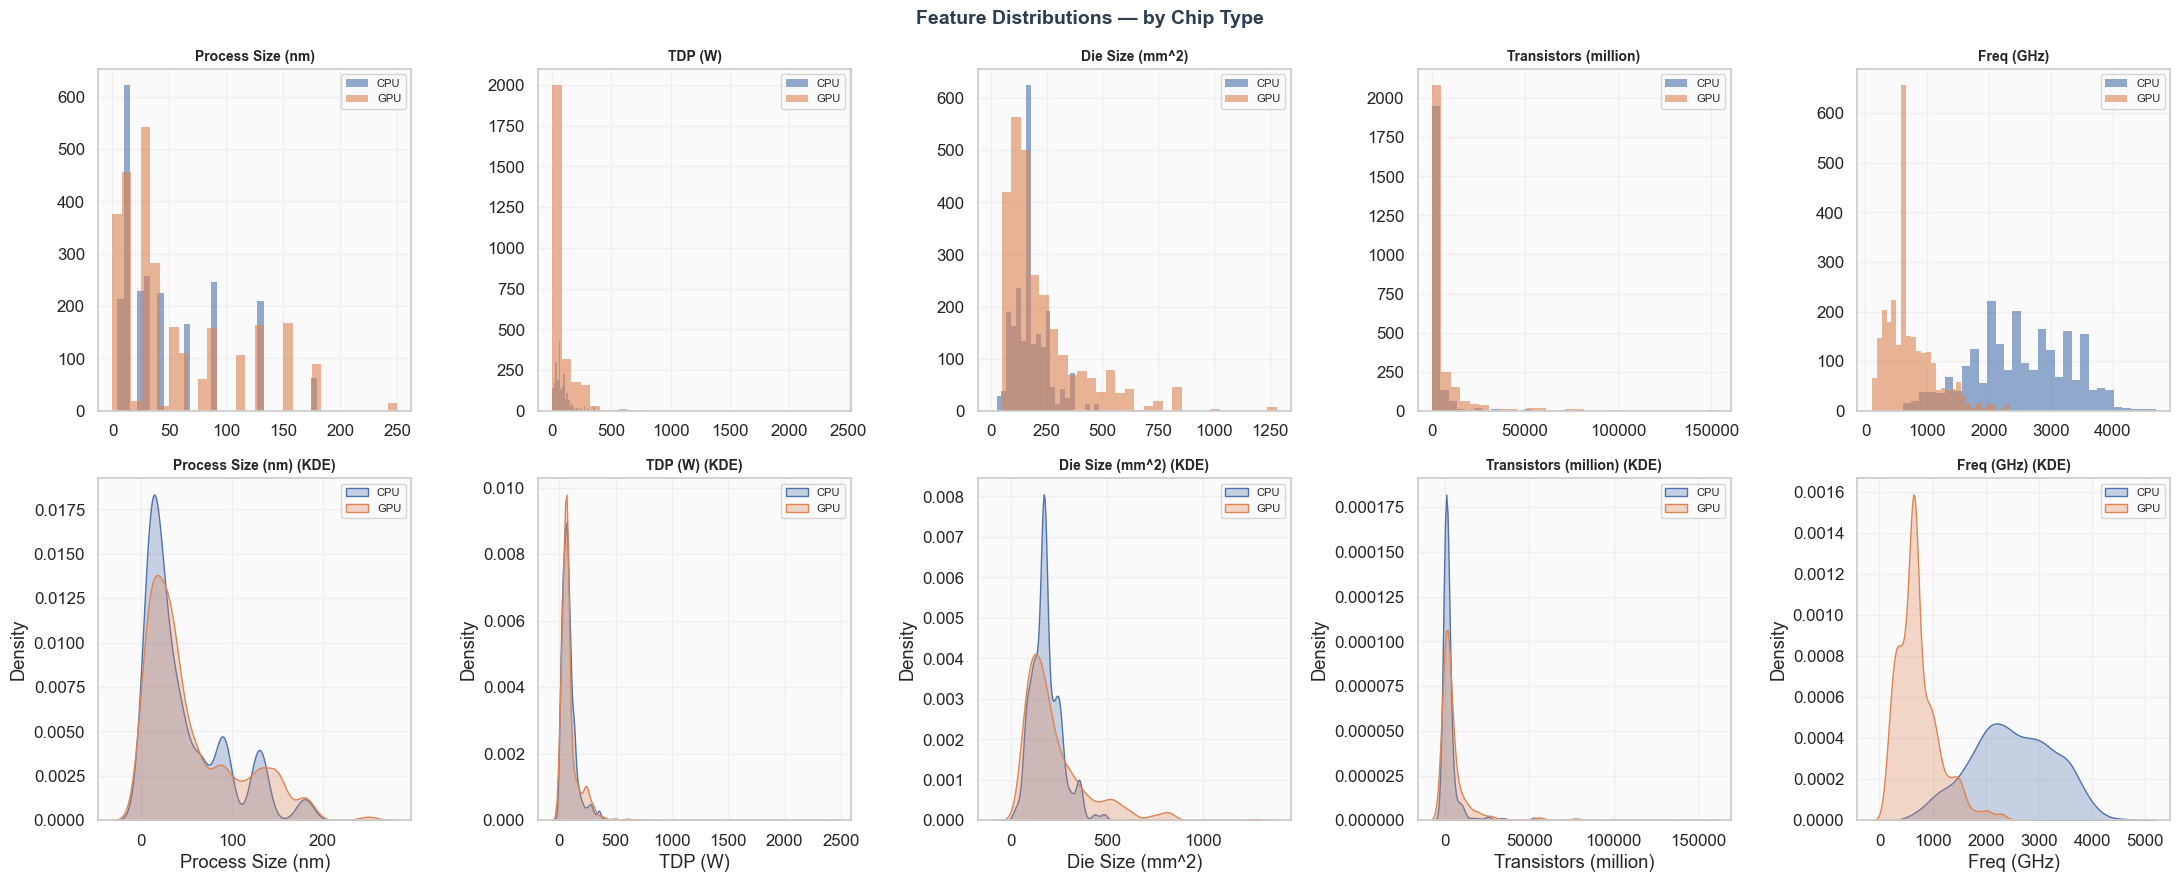

In [23]:
num_feats = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
             'Transistors (million)', 'Freq (GHz)']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("Feature Distributions — by Chip Type",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for i, feat in enumerate(num_feats):
    for t, color in [('CPU', PALETTE['CPU']), ('GPU', PALETTE['GPU'])]:
        d = df_clean[df_clean['Type'] == t][feat].dropna()
        axes[0, i].hist(d, bins=30, alpha=0.6, color=color, label=t, edgecolor='none')
        sns.kdeplot(d, ax=axes[1, i], color=color, fill=True, alpha=0.3, label=t)
    axes[0, i].set_title(feat, fontweight='bold', fontsize=10)
    axes[0, i].legend(fontsize=8)
    axes[1, i].set_title(f'{feat} (KDE)', fontweight='bold', fontsize=10)
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Correlation Analysis

We compute **Pearson correlation matrices** separately for CPU and GPU subsets.  
Numerical features are used; GFLOPS columns are included for GPUs only (all-NaN for CPUs).


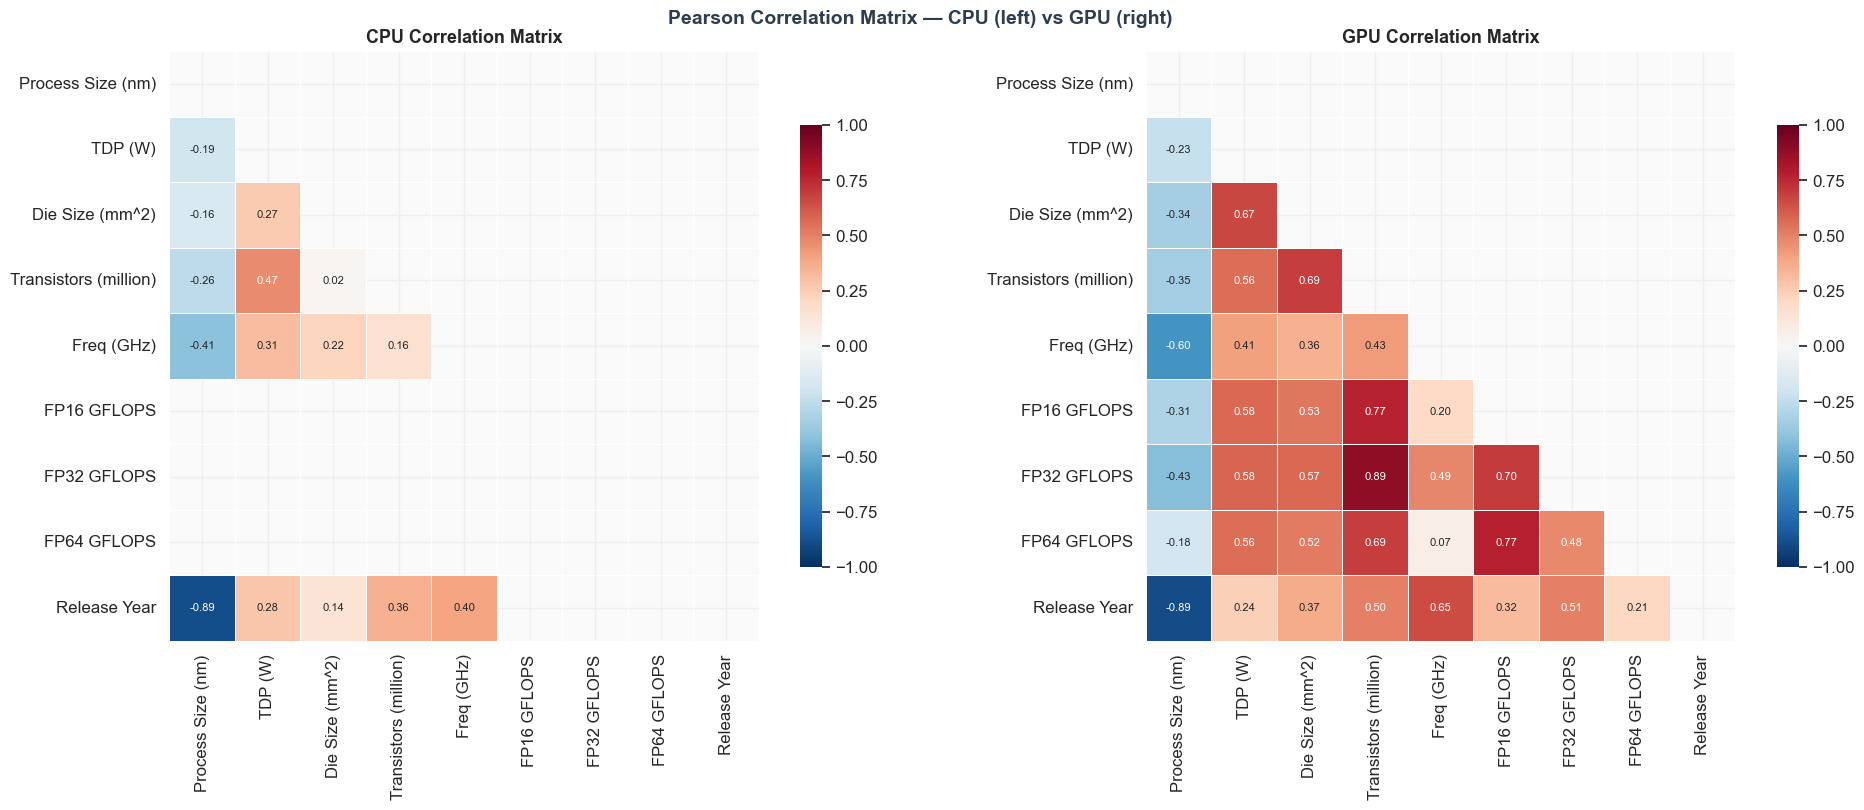

In [24]:
num_features = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
                'Transistors (million)', 'Freq (GHz)',
                'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS', 'Release Year']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Pearson Correlation Matrix — CPU (left) vs GPU (right)",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, subset_type in [(axes[0], 'CPU'), (axes[1], 'GPU')]:
    sub = df_clean[df_clean['Type'] == subset_type][num_features].dropna(thresh=4)
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.75},
        annot_kws={'size': 8}
    )
    ax.set_title(f'{subset_type} Correlation Matrix', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()


**Key correlation insights:**

**CPU:**  
- `Transistors` ↔ `Die Size` and `TDP` ↔ `Die Size` are strongly positively correlated, bigger dies pack more transistors and dissipate more heat.  
- `Process Size` ↔ `Release Year` is strongly negative, newer chips use smaller nodes.  
- `Freq` shows moderate correlation with most features.

**GPU:**  
- All three GFLOPS metrics are very tightly correlated with each other and with `Transistors` and `Die Size`.  
- `Process Size` is negatively correlated with performance metrics, smaller nodes enable more powerful GPUs.


---
## 8. Feature Encoding for Modelling

| Feature | Encoding | Rationale |
|---------|----------|-----------|
| `Type` | **Binary label** (CPU=0, GPU=1) | Only two classes; ordinal relationship acceptable |
| `Vendor` | **Ordinal** (ranked by tech sophistication) | Captures a meaningful order: from legacy/niche → leading-edge designers |
| `Foundry` | **One-Hot** | Purely nominal; no natural order between TSMC, Intel, Samsung, etc. |
| Skewed numerics | **log1p transform** added as new columns | Reduces right-skew; improves linearity assumptions for many models |


In [25]:
df_encoded = df_clean.copy()

# Binary: Type
df_encoded['Type_enc'] = (df_encoded['Type'] == 'GPU').astype(int)
print("Type  → 0=CPU, 1=GPU")

#  Ordinal: Vendor (tech sophistication order) 
vendor_order = ['Matrox', 'XGI', '3dfx', 'VIA', 'Sony', 'ATI', 'AMD', 'Intel', 'NVIDIA']
oe = OrdinalEncoder(
    categories=[vendor_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_encoded['Vendor_enc'] = oe.fit_transform(df_encoded[['Vendor']])
print("Vendor → ordinal:", {v: i for i, v in enumerate(vendor_order)})

#  One-Hot: Foundry 
foundry_dummies = pd.get_dummies(df_encoded['Foundry'], prefix='Foundry', dtype=int)
df_encoded = pd.concat([df_encoded, foundry_dummies], axis=1)
print("Foundry → OHE columns:", foundry_dummies.columns.tolist())

#  log1p transforms for skewed numerics 
skewed = ['Transistors (million)', 'Die Size (mm^2)', 'TDP (W)',
          'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']
for col in skewed:
    if col in df_encoded.columns:
        df_encoded[f'{col}_log'] = np.log1p(df_encoded[col])

# Drop original string columns no longer needed
df_encoded.drop(columns=['Type', 'Vendor', 'Foundry', 'Release Date'],
                inplace=True, errors='ignore')

print(f"\nFinal encoded shape: {df_encoded.shape}")
df_encoded.head(5)


Type  → 0=CPU, 1=GPU
Vendor → ordinal: {'Matrox': 0, 'XGI': 1, '3dfx': 2, 'VIA': 3, 'Sony': 4, 'ATI': 5, 'AMD': 6, 'Intel': 7, 'NVIDIA': 8}
Foundry → OHE columns: ['Foundry_Fujitsu', 'Foundry_GlobalFoundries', 'Foundry_IBM', 'Foundry_Intel', 'Foundry_NEC', 'Foundry_Renesas', 'Foundry_Samsung', 'Foundry_Sony', 'Foundry_TSMC', 'Foundry_UMC', 'Foundry_Unknown']

Final encoded shape: (4945, 29)


,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,Release Year,Release Month,...,Foundry_Sony,Foundry_TSMC,Foundry_UMC,Foundry_Unknown,Transistors (million)_log,Die Size (mm^2)_log,TDP (W)_log,FP16 GFLOPS_log,FP32 GFLOPS_log,FP64 GFLOPS_log
0,180.0,54.0,120.0,37.0,1000.0,NaN,NaN,NaN,2000.0,6.0,...,0,0,0,1,3.637586,4.795791,4.007333,NaN,NaN,NaN
1,180.0,54.0,120.0,37.0,1000.0,NaN,NaN,NaN,2000.0,10.0,...,0,0,0,1,3.637586,4.795791,4.007333,NaN,NaN,NaN
2,180.0,60.0,120.0,37.0,1100.0,NaN,NaN,NaN,2000.0,8.0,...,0,0,0,1,3.637586,4.795791,4.110874,NaN,NaN,NaN
3,180.0,63.0,120.0,37.0,1133.0,NaN,NaN,NaN,2000.0,10.0,...,0,0,0,1,3.637586,4.795791,4.158883,NaN,NaN,NaN
4,180.0,66.0,120.0,37.0,1200.0,NaN,NaN,NaN,2000.0,10.0,...,0,0,0,1,3.637586,4.795791,4.204693,NaN,NaN,NaN


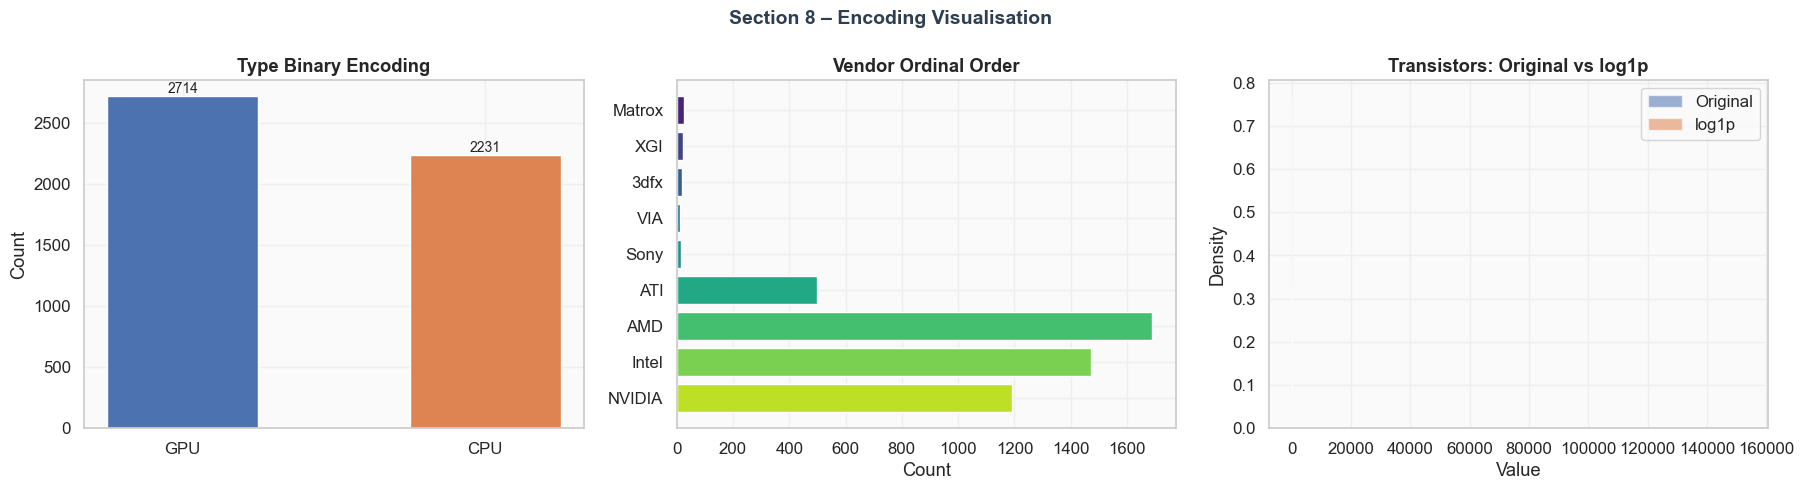

In [26]:
# ── Visualise encoding choices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 8 – Encoding Visualisation",
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

# Type distribution
type_counts = df_encoded['Type_enc'].value_counts().rename({0: 'CPU', 1: 'GPU'})
axes[0].bar(type_counts.index, type_counts.values,
            color=[PALETTE['CPU'], PALETTE['GPU']], edgecolor='white', width=0.5)
axes[0].set_title("Type Binary Encoding", fontweight='bold')
axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Vendor ordinal
v_counts = df_clean['Vendor'].value_counts().reindex(vendor_order, fill_value=0)
axes[1].barh(range(len(v_counts)), v_counts.values,
             color=plt.cm.viridis(np.linspace(0.1, 0.9, len(v_counts))))
axes[1].set_yticks(range(len(v_counts)))
axes[1].set_yticklabels(v_counts.index)
axes[1].set_xlabel("Count"); axes[1].set_title("Vendor Ordinal Order", fontweight='bold')
axes[1].invert_yaxis()

# Skew comparison: Transistors before / after log
orig = df_clean['Transistors (million)'].dropna()
log_ = np.log1p(orig)
axes[2].hist(orig, bins=50, alpha=0.55, color=PALETTE['CPU'],  label='Original', density=True)
axes[2].hist(log_, bins=50, alpha=0.55, color=PALETTE['GPU'], label='log1p', density=True)
axes[2].set_title("Transistors: Original vs log1p", fontweight='bold')
axes[2].set_xlabel("Value"); axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.savefig('encoding.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Save Processed Datasets


In [28]:
df_clean.to_csv('chip_dataset_clean.csv', index=False)
df_encoded.to_csv('chip_dataset_encoded.csv', index=False)



---
## Summary

| Step | Action | Output |
|------|--------|--------|
| Missingness | Replaced `'unknown'` strings; visualised with `missingno` | 4-panel missingness overview |
| Imputation | Group-median for numeric; `'Unknown'` label for Foundry; retain NaN for GFLOPS | `df_clean` |
| Drop | Removed `Product` (identifier) | — |
| Temporal | Parsed `Release Date` → datetime; extracted Year + Month | `Release Year`, `Release Month` |
| EDA | Validated all 8 industry assumptions | 10 figures |
| Correlation | Pearson heatmaps split by CPU/GPU | `fig11_correlation.png` |
| Encoding | Binary (Type), Ordinal (Vendor), OHE (Foundry), log1p transforms | `chip_dataset_encoded.csv` (29 cols) |
